In [1]:
# PROJECT DIRECTORY SETUP

from pathlib import Path

# The notebook is inside the project folder (amazon_customer_service_ai)
PROJECT_ROOT = Path.cwd()

# Define project directories
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
REPORTS_DIR = OUTPUTS_DIR / "reports"

# List of all directories to create
directories = [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MODELS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    REPORTS_DIR
]

# Create directories automatically
for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory structure created successfully.\n")

for directory in directories:
    print(f"✓ {directory.relative_to(PROJECT_ROOT)}")

Project directory structure created successfully.

✓ data\raw
✓ data\processed
✓ models
✓ outputs\figures
✓ outputs\tables
✓ outputs\reports


In [4]:
# IMPORT LIBRARIES

from datasets import load_dataset
from itertools import islice
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")

C:\Users\LAPTOP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.
Python version: 3.14.6
Pandas version: 3.0.3


In [14]:
# LOAD AMAZON REVIEWS 2023 DATASET

# Define file path
DATA_FILE = RAW_DATA_DIR / "Amazon_reviews_2023.csv"

# Check whether the file exists
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_FILE}\n"
        "Please place Amazon_reviews_2023.csv inside the data/raw folder."
    )

print("Dataset file found successfully.")
print(f"File size: {DATA_FILE.stat().st_size / (1024**2):.2f} MB")

Dataset file found successfully.
File size: 222.27 MB


In [15]:
# LOAD THE DATASET

print("Loading Amazon Reviews 2023 dataset...")

df = pd.read_csv(
    DATA_FILE,
    low_memory=False
)

print("\nDataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Loading Amazon Reviews 2023 dataset...

Dataset loaded successfully.
Rows    : 701,528
Columns : 10


In [16]:
# INITIAL DATASET INSPECTION

print("=" * 40)
print("AMAZON REVIEWS 2023 - DATASET OVERVIEW")
print("=" * 40)

print(f"\nDataset shape: {df.shape}")

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

print("\nData types:")
print(df.dtypes)

print("\nFirst five rows:")
display(df.head())

AMAZON REVIEWS 2023 - DATASET OVERVIEW

Dataset shape: (701528, 10)

Column names:
1. rating
2. title
3. text
4. images
5. asin
6. parent_asin
7. user_id
8. timestamp
9. helpful_vote
10. verified_purchase

Data types:
rating               int64
title                  str
text                   str
images                 str
asin                   str
parent_asin            str
user_id                str
timestamp              str
helpful_vote         int64
verified_purchase     bool
dtype: object

First five rows:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [17]:
# INITIAL DATA QUALITY CHECK

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2),
    "Unique_Values": df.nunique()
})

display(missing_summary)

,Missing_Count,Missing_Percentage,Unique_Values
rating,0,0.00,5
title,160,0.02,376390
text,212,0.03,643624
images,0,0.00,58938
asin,0,0.00,115709
parent_asin,0,0.00,112565
user_id,0,0.00,631986
timestamp,0,0.00,694027
helpful_vote,0,0.00,240
verified_purchase,0,0.00,2


In [18]:
# DATA QUALITY PROCESSING

# Drop rows with missing review text
df = df.dropna(subset=["text"])

# Fill missing titles with an empty string
df["title"] = df["title"].fillna("")

# Reset index
df = df.reset_index(drop=True)

print("Remaining missing values:", df.isnull().sum().sum())
print("Final dataset shape:", df.shape)

Remaining missing values: 0
Final dataset shape: (701316, 10)


In [19]:
# IDENTIFY RATING AND TEXT COLUMNS

# Standardise column names for easier processing
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Standardised column names:")
print(df.columns.tolist())

# Check essential columns
required_columns = ["rating", "text"]

for column in required_columns:
    if column in df.columns:
        print(f"✓ '{column}' found")
    else:
        print(f"✗ '{column}' not found")

Standardised column names:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
✓ 'rating' found
✓ 'text' found


In [22]:
# DUPLICATE REVIEW PROCESSING

# Check duplicate reviews
print("Duplicate reviews:", df["text"].duplicated().sum())

# Remove duplicate reviews
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Duplicate reviews: 57692
Dataset shape after removing duplicates: (643624, 10)


sentiment
Positive    450373
Negative    139169
Neutral      54082
Name: count, dtype: int64

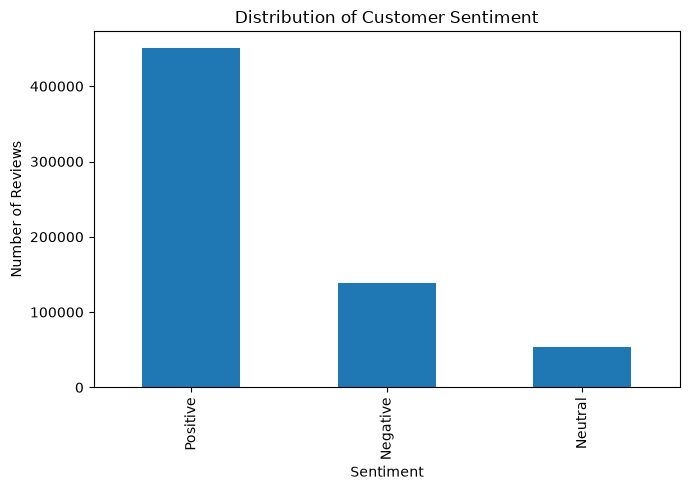

In [24]:
# SENTIMENT LABELS FROM RATINGS

def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["rating"].apply(get_sentiment)

# Sentiment distribution
sentiment_distribution = df["sentiment"].value_counts()

display(sentiment_distribution)

# Simple bar chart
plt.figure(figsize=(7, 5))
sentiment_distribution.plot(kind="bar")

plt.title("Distribution of Customer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [25]:
# COMBINE REVIEW & TITLE TEXT

df["review_text"] = df["title"] + " " + df["text"]

# Remove extra spaces
df["review_text"] = df["review_text"].str.strip()

df[["title", "text", "review_text"]].head()

,title,text,review_text
0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,Such a lovely scent but not overpowering. This...
1,Works great but smells a little weird.,"This product does what I need it to do, I just...",Works great but smells a little weird. This pr...
2,Yes!,"Smells good, feels great!","Yes! Smells good, feels great!"
3,Synthetic feeling,Felt synthetic,Synthetic feeling Felt synthetic
4,A+,Love it,A+ Love it


In [26]:
# RELEVANT REVIEWS

# Customer service-related keywords
service_keywords = [
    "delivery",
    "shipping",
    "customer service",
    "customer support",
    "refund",
    "return",
    "replacement",
    "package",
    "packaging",
    "arrived late",
    "late delivery",
    "damaged",
    "seller",
    "order"
]

# Create service-related review indicator
pattern = "|".join(service_keywords)

df["service_related"] = (
    df["review_text"]
    .str.lower()
    .str.contains(pattern, na=False)
)

# Check distribution
print(df["service_related"].value_counts())

# Keep only customer-service-related reviews
service_df = df[df["service_related"] == True].copy()

print("Total reviews:", len(df))
print("Service-related reviews:", len(service_df))

# Display example service-related reviews
service_df[
    ["rating", "sentiment", "review_text"]
].head(10)

service_related
False    561160
True      82464
Name: count, dtype: int64
Total reviews: 643624
Service-related reviews: 82464


,rating,sentiment,review_text
14,5,Positive,Great refreshing skin care routine! I had neve...
15,3,Neutral,Didn't do much and difficult to place and main...
21,5,Positive,Great combo pack. Wish I had been using this y...
27,1,Negative,not what it claims to do nothing special unfo...
34,3,Neutral,replacement filing discs I purchased the tool ...
42,5,Positive,Really nice quality These are not what I was e...
48,4,Positive,Did the job and looked great Loved it. The wor...
66,4,Positive,Not 100% sure how safe it is particularly for ...
81,5,Positive,Best Face Wipes! I have tried several differen...
84,4,Positive,Nice Variety of Colors This set of gel nail po...


,Count,Percentage
rating,,
1,102067,14.55
2,43032,6.14
3,56294,8.03
4,79357,11.32
5,420566,59.97


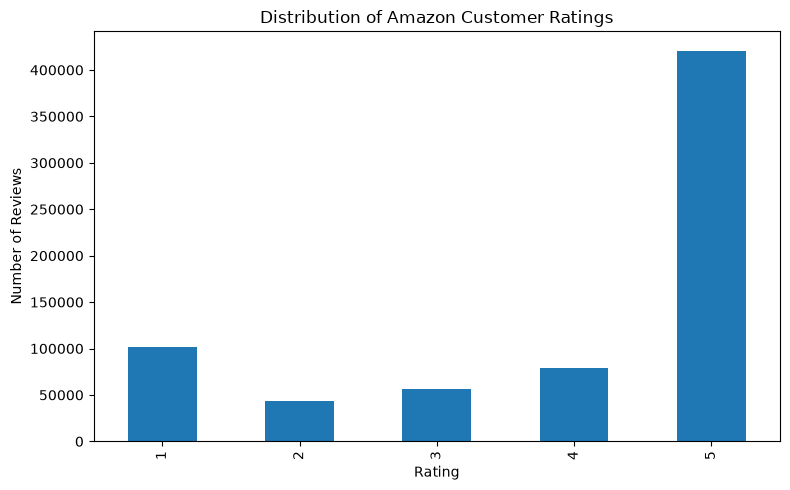

In [21]:
# RATING DISTRIBUTION

# Rating distribution table
rating_distribution = df["rating"].value_counts().sort_index()

rating_table = pd.DataFrame({
    "Count": rating_distribution,
    "Percentage": (rating_distribution / len(df) * 100).round(2)
})

display(rating_table)

# Bar chart
plt.figure(figsize=(8, 5))
rating_distribution.plot(kind="bar")

plt.title("Distribution of Amazon Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

sentiment
Positive    49341
Negative    26347
Neutral      6776
Name: count, dtype: int64

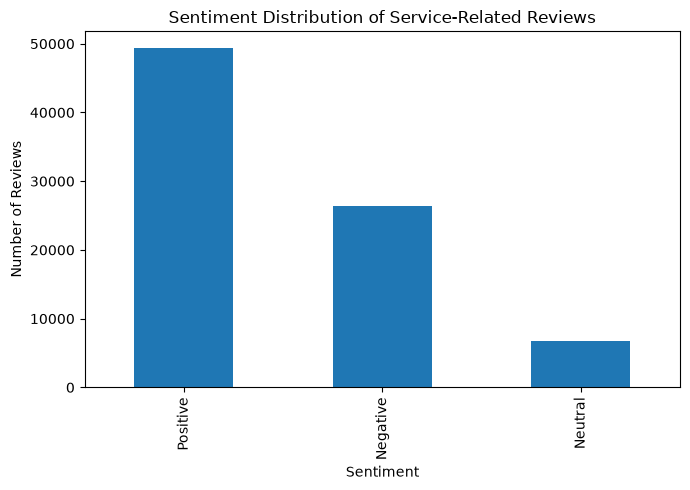

In [27]:
# EDA: SENTIMENT DISTRIBUTION OF SERVICE-RELATED REVIEWS

service_sentiment = service_df["sentiment"].value_counts()

display(service_sentiment)

service_sentiment.plot(kind="bar", figsize=(7, 5))

plt.title("Sentiment Distribution of Service-Related Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

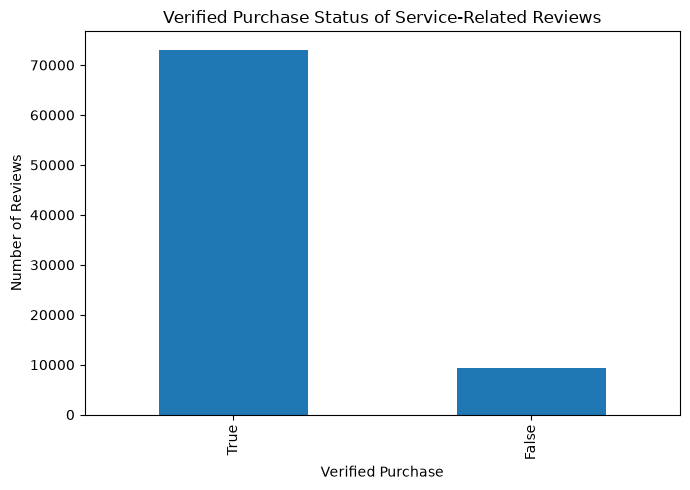

In [28]:
# EDA: VERIFIED PURCHASE DISTRIBUTION

service_df["verified_purchase"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Verified Purchase Status of Service-Related Reviews")
plt.xlabel("Verified Purchase")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [29]:
# TEXT PREPROCESSING

# Simple text preprocessing
service_df["clean_text"] = (
    service_df["review_text"]
    .str.lower()
    .str.replace(r"[^a-zA-Z\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# View cleaned text
service_df[["review_text", "clean_text"]].head()

# Remove empty cleaned reviews
service_df = service_df[
    service_df["clean_text"].str.len() > 0
].reset_index(drop=True)

print("Final number of service-related reviews:", len(service_df))

Final number of service-related reviews: 82464


In [30]:
# FEATURE ENGINEERING

X = service_df["clean_text"]
y = service_df["sentiment"]
print(y.value_counts())

sentiment
Positive    49341
Negative    26347
Neutral      6776
Name: count, dtype: int64


In [31]:
# TRAIN-TEST SPLIT (80-20)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 65971
Testing samples: 16493


In [32]:
# TF-IDF FEATURE EXTRACTION

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (65971, 5000)
Testing feature shape: (16493, 5000)


In [33]:
# MODEL 1: LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test_tfidf)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.8525

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.88      0.84      5270
     Neutral       0.44      0.09      0.15      1355
    Positive       0.89      0.94      0.92      9868

    accuracy                           0.85     16493
   macro avg       0.71      0.64      0.64     16493
weighted avg       0.83      0.85      0.83     16493



In [34]:
# MODEL 2: MULTINOMIAL NAIVE BAYES

from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

# Predictions
nb_predictions = nb_model.predict(X_test_tfidf)

# Accuracy
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", round(nb_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 0.8311

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.80      0.81      5270
     Neutral       0.38      0.00      0.00      1355
    Positive       0.83      0.96      0.89      9868

    accuracy                           0.83     16493
   macro avg       0.68      0.59      0.57     16493
weighted avg       0.79      0.83      0.79     16493



In [35]:
# MODEL 3: LINEAR SVM

from sklearn.svm import LinearSVC

# Train Linear SVM
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

# Predictions
svm_predictions = svm_model.predict(X_test_tfidf)

# Accuracy
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("Linear SVM Accuracy:", round(svm_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))

Linear SVM Accuracy: 0.8489

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.87      0.84      5270
     Neutral       0.42      0.08      0.13      1355
    Positive       0.89      0.94      0.91      9868

    accuracy                           0.85     16493
   macro avg       0.70      0.63      0.63     16493
weighted avg       0.82      0.85      0.82     16493



In [36]:
# COMPARATIVE ANALYSIS

from sklearn.metrics import f1_score

# Calculate F1 scores
lr_f1 = f1_score(y_test, lr_predictions, average="weighted")
nb_f1 = f1_score(y_test, nb_predictions, average="weighted")
svm_f1 = f1_score(y_test, svm_predictions, average="weighted")

# Create comparison table
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy
    ],
    "Weighted F1 Score": [
        lr_f1,
        nb_f1,
        svm_f1
    ]
})

model_results[["Accuracy", "Weighted F1 Score"]] = (
    model_results[["Accuracy", "Weighted F1 Score"]].round(4)
)

display(model_results)

,Model,Accuracy,Weighted F1 Score
0,Logistic Regression,0.8525,0.8286
1,Naive Bayes,0.8311,0.7944
2,Linear SVM,0.8489,0.8237


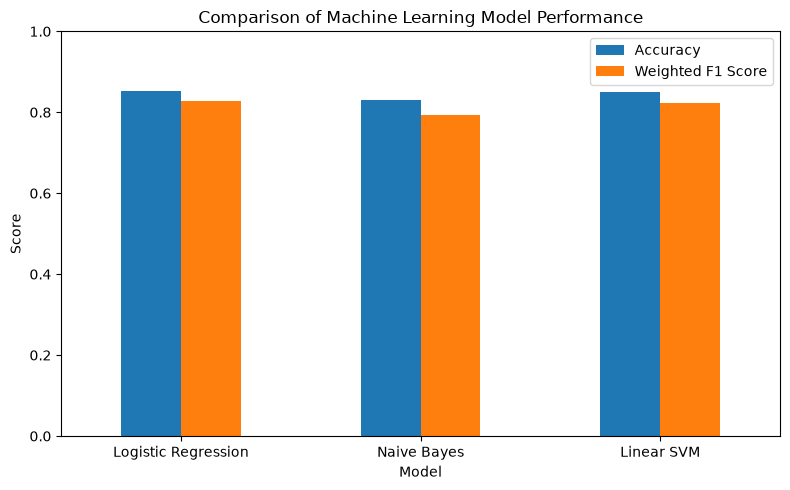

In [43]:
# MODEL COMPARISON CHART

model_results.set_index("Model")[
    ["Accuracy", "Weighted F1 Score"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparison of Machine Learning Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [39]:
# SELECT & SAVE BEST MODEL

import joblib

# Select the best model based on Weighted F1 Score
best_model_name = model_results.loc[
    model_results["Weighted F1 Score"].idxmax(), "Model"
]

# Select the corresponding trained model
if best_model_name == "Logistic Regression":
    best_model = lr_model
elif best_model_name == "Naive Bayes":
    best_model = nb_model
else:
    best_model = svm_model

# Save the best model and TF-IDF vectorizer
joblib.dump(best_model, MODELS_DIR / "best_sentiment_model.pkl")
joblib.dump(tfidf, MODELS_DIR / "tfidf_vectorizer.pkl")

print("Best model:", best_model_name)
print("Best model and TF-IDF vectorizer saved successfully.")

Best model: Logistic Regression
Best model and TF-IDF vectorizer saved successfully.


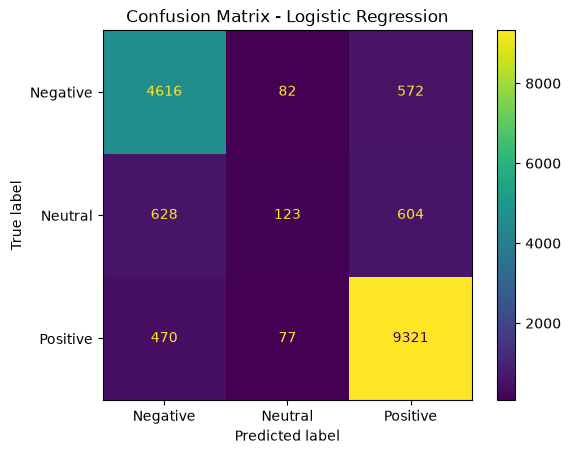

In [41]:
# CONFUSION MATRIX FOR BEST MODEL

from sklearn.metrics import ConfusionMatrixDisplay

# Select predictions of the best model
if best_model_name == "Logistic Regression":
    best_predictions = lr_predictions

elif best_model_name == "Naive Bayes":
    best_predictions = nb_predictions

else:
    best_predictions = svm_predictions

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, best_predictions)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [42]:
# SAVE MODEL COMPARISON RESULTS

model_results.to_csv(
    TABLES_DIR / "model_comparison.csv",
    index=False
)

# Save processed service-related reviews
service_df.to_csv(
    PROCESSED_DATA_DIR / "service_related_reviews.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
